## DP1 ECDFS image products

## Matched ComCam--VIRCAM coadd cutouts

This notebook creates a publication-quality comparison of the same ECDFS
region in the six ComCam bands, u,g,r,i,z,y, and the five VIRCAM
bands, Z,Y,J,H,Ks.

It is designed to run on the **UK Rubin Science Platform**. The standard
DP1 ComCam images are read from the `dp1` Butler repository, while the
processed VIRCAM products are read from the `lsst-ir-fusion-dp1`
repository. Both sets of coadds use the `lsst_cells_v1` skymap, so the
cutouts have a common centre, angular size, pixel scale, and pixel grid.

Display limits are estimated independently in each band to reveal faint
structure. The figure is therefore intended to compare source appearance
and detectability across wavelength, rather than to compare displayed
surface brightness on one common intensity scale.

### 1. Imports and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from astropy.visualization import AsinhStretch, ImageNormalize

import lsst.daf.butler as dafButler
import lsst.geom as geom


# ------------------------------------------------------------------
# UK RSP Butler repositories and collections
# ------------------------------------------------------------------

# Standard Rubin DP1 ComCam products.
COMCAM_REPO = "dp1"
COMCAM_COLLECTION = "LSSTComCam/DP1"
COMCAM_DATASET_TYPE = "deep_coadd"

# VIRCAM products generated by the LSST--VISTA fusion processing.
VIRCAM_REPO = "lsst-ir-fusion-dp1"
VIRCAM_DATASET_TYPE = "deepCoadd_calexp"

# Search all collections in the fusion repository, following the
# discovery pattern used in the UK RSP introduction notebook. DatasetRefs
# are then retrieved directly, so no collection needs to be guessed again.
VIRCAM_SEARCH_COLLECTIONS = ...

# Prefer the validated coadd-output run if the same dataset is visible
# through more than one collection.
VIRCAM_PREFERRED_RUN = (
    "u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z"
)

SKYMAP = "lsst_cells_v1"


# ------------------------------------------------------------------
# Target
# ------------------------------------------------------------------

TARGET_NAME = "SMDG-J0333094-280938"
TARGET_RA_DEG = 53.28911
TARGET_DEC_DEG = -28.16056

# The coadds use a 0.2-arcsec pixel grid. A 300-pixel cutout is
# therefore approximately 60 arcsec wide.
PIXEL_SCALE_ARCSEC = 0.2
CUTOUT_SIZE_PIX = 300
SCALE_BAR_ARCSEC = 10.0


# ------------------------------------------------------------------
# Bands
# ------------------------------------------------------------------

COMCAM_BANDS = ["u", "g", "r", "i", "z", "y"]
VIRCAM_BANDS = ["Z", "Y", "J", "H", "K"]
ALL_BANDS = COMCAM_BANDS + VIRCAM_BANDS

PANEL_LABELS = {
    "u": r"u",
    "g": r"g",
    "r": r"r",
    "i": r"i",
    "z": r"z",
    "y": r"y",
    "Z": r"Z",
    "Y": r"Y",
    "J": r"J",
    "H": r"H",
    "K": r"Ks",
}


# ------------------------------------------------------------------
# Display settings
# ------------------------------------------------------------------
#cmap_name=CMAP_NAME


DISPLAY_LOW_SIGMA = 1.0
DISPLAY_HIGH_PERCENTILE = 99.7
DISPLAY_ASINH_A = 0.04

# Optional per-band tuning after inspecting the first result.
DISPLAY_OVERRIDES = {
    # "u": {"high_percentile": 99.5},
    # "K": {"high_percentile": 99.8},
}


# ------------------------------------------------------------------
# Output
# ------------------------------------------------------------------

OUTDIR = Path("data/image_products")
OUTDIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PDF = OUTDIR / "dp1_ecdfs_11band_matched_cutouts.pdf"
OUTPUT_PNG = OUTDIR / "dp1_ecdfs_11band_matched_cutouts.png"

print("ComCam repository       :", COMCAM_REPO)
print("ComCam collection       :", COMCAM_COLLECTION)
print("VIRCAM repository       :", VIRCAM_REPO)
print("VIRCAM collection search: all repository collections")
print("Target                  :", TARGET_NAME)
print("RA, Dec [deg]           :", TARGET_RA_DEG, TARGET_DEC_DEG)
print("Cutout width [arcsec]   :", CUTOUT_SIZE_PIX * PIXEL_SCALE_ARCSEC)
print("Output PDF              :", OUTPUT_PDF)

ComCam repository       : dp1
ComCam collection       : LSSTComCam/DP1
VIRCAM repository       : lsst-ir-fusion-dp1
VIRCAM collection search: all repository collections
Target                  : SMDG-J0333094-280938
RA, Dec [deg]           : 53.28911 -28.16056
Cutout width [arcsec]   : 60.0
Output PDF              : data/image_products/dp1_ecdfs_11band_matched_cutouts.pdf


### 2. Open the UK RSP Butlers and identify the target tract and patch

In [2]:
# The standard DP1 Butler is opened with its default ComCam collection.
butler_comcam = dafButler.Butler(
    COMCAM_REPO,
    collections=COMCAM_COLLECTION,
)

# The fusion repository is opened separately because it contains the
# processed VIRCAM products and their catalogue outputs.
butler_vista = dafButler.Butler(VIRCAM_REPO)

registry_comcam = butler_comcam.registry
registry_vista = butler_vista.registry

# The standard DP1 skymap defines the common tract and patch geometry.
skymap = butler_comcam.get("skyMap")

target = geom.SpherePoint(
    TARGET_RA_DEG * geom.degrees,
    TARGET_DEC_DEG * geom.degrees,
)

tract_info = skymap.findTract(target)
patch_info = tract_info.findPatch(target)

TRACT = tract_info.getId()
PATCH = patch_info.getSequentialIndex()

print("Opened ComCam Butler:", COMCAM_REPO)
print("Opened VIRCAM Butler:", VIRCAM_REPO)
print("Target tract        :", TRACT)
print("Target patch        :", PATCH)
print(
    "Target data ID      :",
    {
        "skymap": SKYMAP,
        "tract": TRACT,
        "patch": PATCH,
    },
)

Opened ComCam Butler: dp1
Opened VIRCAM Butler: lsst-ir-fusion-dp1
Target tract        : 5063
Target patch        : 13
Target data ID      : {'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}


### 3. Helper functions for querying RSP coadds and extracting matched cutouts

In [3]:
def data_id_to_dict(data_id):
    """Convert a Butler DataCoordinate to a normal dictionary."""
    for attribute in ("required", "mapping"):
        try:
            return dict(getattr(data_id, attribute))
        except Exception:
            pass

    try:
        return {key: data_id[key] for key in data_id.keys()}
    except Exception:
        return str(data_id)


def query_single_comcam_coadd(band):
    """Retrieve one standard DP1 ComCam deep coadd."""
    refs = list(
        set(
            butler_comcam.query_datasets(
                COMCAM_DATASET_TYPE,
                tract=TRACT,
                patch=PATCH,
                where=f"band = '{band}'",
            )
        )
    )

    if len(refs) == 0:
        raise RuntimeError(
            f"No ComCam {band}-band {COMCAM_DATASET_TYPE} was found "
            f"for tract={TRACT}, patch={PATCH}."
        )

    if len(refs) > 1:
        print(
            f"Warning: found {len(refs)} ComCam refs for band {band}; "
            "using the first returned reference."
        )

    ref = refs[0]
    exposure = butler_comcam.get(ref)
    return exposure, ref


def discover_vista_coadd_refs():
    """
    Discover all VIRCAM coadd refs at the target patch.

    The query searches all collections, as in the UK RSP introduction
    notebook. This avoids assuming that the chained collection exposes
    every band in exactly the same way as its output RUN collection.
    """
    base_data_id = {
        "skymap": SKYMAP,
        "tract": TRACT,
        "patch": PATCH,
    }

    refs = list(
        set(
            registry_vista.queryDatasets(
                VIRCAM_DATASET_TYPE,
                dataId=base_data_id,
                collections=VIRCAM_SEARCH_COLLECTIONS,
            )
        )
    )

    if len(refs) == 0:
        raise RuntimeError(
            "No VIRCAM deep coadds were found at "
            f"tract={TRACT}, patch={PATCH} in any collection."
        )

    refs = sorted(
        refs,
        key=lambda ref: (
            str(ref.dataId["band"]),
            str(ref.run),
        ),
    )

    print("\nVIRCAM coadds discovered at the target patch:")
    for ref in refs:
        print(
            " ",
            ref.datasetType.name,
            data_id_to_dict(ref.dataId),
            "run=",
            ref.run,
        )

    available_bands = sorted(
        {
            str(ref.dataId["band"])
            for ref in refs
        }
    )
    print("Available VIRCAM bands:", available_bands)

    return refs


def select_vista_ref(refs, band):
    """Select the preferred DatasetRef for one VIRCAM band."""
    candidates = [
        ref
        for ref in refs
        if str(ref.dataId["band"]) == band
    ]

    if len(candidates) == 0:
        available_bands = sorted(
            {
                str(ref.dataId["band"])
                for ref in refs
            }
        )
        raise RuntimeError(
            f"No VIRCAM {band}-band {VIRCAM_DATASET_TYPE} was found "
            f"for tract={TRACT}, patch={PATCH}. "
            f"Available bands are {available_bands}."
        )

    preferred = [
        ref
        for ref in candidates
        if ref.run == VIRCAM_PREFERRED_RUN
    ]

    if preferred:
        return preferred[0]

    if len(candidates) > 1:
        print(
            f"Warning: found {len(candidates)} VIRCAM refs for band "
            f"{band}; the preferred run was not present, so the final "
            "sorted reference will be used."
        )

    return sorted(
        candidates,
        key=lambda ref: str(ref.run),
    )[-1]


def make_cutout_bbox(exposure, sky_position, size_pix):
    """Construct a square parent-coordinate bounding box."""
    centre = geom.Point2I(
        exposure.getWcs().skyToPixel(sky_position)
    )
    extent = geom.Extent2I(size_pix, size_pix)
    minimum = centre - extent // 2
    bbox = geom.Box2I(minimum, extent)

    if not exposure.getBBox().contains(bbox):
        raise ValueError(
            "Requested cutout is not fully contained in the exposure: "
            f"requested={bbox}, exposure={exposure.getBBox()}"
        )

    return bbox


def extract_cutout(exposure, sky_position, size_pix):
    """Return an exposure cutout and a masked display array."""
    bbox = make_cutout_bbox(
        exposure,
        sky_position,
        size_pix,
    )
    cutout = exposure.getCutout(bbox)

    array = np.asarray(
        cutout.image.array,
        dtype=float,
    ).copy()

    mask_dict = cutout.mask.getMaskPlaneDict()

    if "NO_DATA" in mask_dict:
        bit = mask_dict["NO_DATA"]
        no_data = (
            np.asarray(cutout.mask.array, dtype=np.int64)
            & (1 << bit)
        ) != 0
        array[no_data] = np.nan
    else:
        no_data = np.zeros(array.shape, dtype=bool)

    array[~np.isfinite(array)] = np.nan
    return cutout, array, no_data


def robust_sigma(values):
    """Return a Gaussian-equivalent MAD scatter."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return np.nan

    median = np.median(values)
    mad = np.median(np.abs(values - median))
    return 1.4826 * mad


def display_normalization(array, band):
    """Construct an independent robust asinh normalization."""
    finite = np.asarray(array, dtype=float)
    finite = finite[np.isfinite(finite)]

    if finite.size == 0:
        raise ValueError(
            f"No finite pixels are available in band {band}."
        )

    median = np.median(finite)
    sigma = robust_sigma(finite)

    settings = {
        "low_sigma": DISPLAY_LOW_SIGMA,
        "high_percentile": DISPLAY_HIGH_PERCENTILE,
        "asinh_a": DISPLAY_ASINH_A,
    }
    settings.update(DISPLAY_OVERRIDES.get(band, {}))

    if not np.isfinite(sigma) or sigma <= 0:
        sigma = np.std(finite)

    vmin = median - settings["low_sigma"] * sigma
    vmax = np.percentile(
        finite,
        settings["high_percentile"],
    )

    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = median + 10.0 * sigma

    norm = ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(a=settings["asinh_a"]),
        clip=True,
    )

    return norm, vmin, vmax

### 4. Load all eleven coadds

The six optical bands are retrieved from the standard DP1
`LSSTComCam/DP1` collection. The five near-infrared bands are retrieved
from the `lsst-ir-fusion-dp1` Butler repository.

In [4]:
exposures = {}
provenance = {}

for band in COMCAM_BANDS:
    exposure, ref = query_single_comcam_coadd(band)
    exposures[band] = exposure
    provenance[band] = {
        "instrument": "ComCam",
        "dataset_type": ref.datasetType.name,
        "data_id": data_id_to_dict(ref.dataId),
        "run": ref.run,
    }
    print(
        f"Loaded ComCam {band}: "
        f"{ref.datasetType.name} {data_id_to_dict(ref.dataId)}"
    )


# Discover all VIRCAM bands in one query before loading any images.
vista_refs = discover_vista_coadd_refs()

for band in VIRCAM_BANDS:
    ref = select_vista_ref(
        vista_refs,
        band,
    )
    exposure = butler_vista.get(ref)

    exposures[band] = exposure
    provenance[band] = {
        "instrument": "VIRCAM",
        "dataset_type": ref.datasetType.name,
        "data_id": data_id_to_dict(ref.dataId),
        "run": ref.run,
    }
    print(
        f"Loaded VIRCAM {band}: "
        f"{ref.datasetType.name} {data_id_to_dict(ref.dataId)}"
    )

print(f"\nLoaded {len(exposures)} / {len(ALL_BANDS)} bands.")

Loaded ComCam u: deep_coadd {'band': 'u', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
Loaded ComCam g: deep_coadd {'band': 'g', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
Loaded ComCam r: deep_coadd {'band': 'r', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
Loaded ComCam i: deep_coadd {'band': 'i', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
Loaded ComCam z: deep_coadd {'band': 'z', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
Loaded ComCam y: deep_coadd {'band': 'y', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}

VIRCAM coadds discovered at the target patch:
  deepCoadd_calexp {'band': 'H', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'J', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}

### 5. Extract matched cutouts and inspect their coverage

In [5]:
cutout_exposures = {}
cutout_arrays = {}
summary_rows = []

for band in ALL_BANDS:
    cutout, array, no_data = extract_cutout(
        exposures[band],
        target,
        CUTOUT_SIZE_PIX,
    )

    cutout_exposures[band] = cutout
    cutout_arrays[band] = array

    summary_rows.append(
        {
            "instrument": provenance[band]["instrument"],
            "band": PANEL_LABELS[band].replace("$", ""),
            "shape_y": array.shape[0],
            "shape_x": array.shape[1],
            "finite_fraction": np.mean(np.isfinite(array)),
            "no_data_fraction": np.mean(no_data),
            "run": provenance[band]["run"],
        }
    )

summary = pd.DataFrame(summary_rows)
display(summary)

shapes = {
    array.shape
    for array in cutout_arrays.values()
}
if len(shapes) != 1:
    raise RuntimeError(
        f"The cutouts do not have a common array shape: {shapes}"
    )

print("Common cutout shape:", shapes.pop())


# ------------------------------------------------------------
# Shared normalization for all 11 panels
# ------------------------------------------------------------
all_finite = np.concatenate(
    [
        cutout_arrays[band][np.isfinite(cutout_arrays[band])]
        for band in ALL_BANDS
    ]
)

shared_norm, shared_vmin, shared_vmax = display_normalization(
    all_finite,
    "shared",
)

normalizations = {
    band: shared_norm
    for band in ALL_BANDS
}

print(
    f"Shared display limits: "
    f"vmin={shared_vmin:.6g}, vmax={shared_vmax:.6g}"
)

,instrument,band,shape_y,shape_x,finite_fraction,no_data_fraction,run
0,ComCam,u,300,300,1.0,0.0,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
1,ComCam,g,300,300,1.0,0.0,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
2,ComCam,r,300,300,1.0,0.0,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
3,ComCam,i,300,300,1.0,0.0,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
4,ComCam,z,300,300,1.0,0.0,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
5,ComCam,y,300,300,1.0,0.0,LSSTComCam/runs/DRP/DP1/DM-51335/deep_coadd
6,VIRCAM,Z,300,300,1.0,0.0,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
7,VIRCAM,Y,300,300,1.0,0.0,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
8,VIRCAM,J,300,300,1.0,0.0,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
9,VIRCAM,H,300,300,1.0,0.0,u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


Common cutout shape: (300, 300)
Shared display limits: vmin=-1.7348, vmax=300.499


### 6. Create the publication figure

Each image spans two grid columns. The six ComCam panels fill the
top row, while the five VIRCAM panels are shifted by one grid column so
that they are centred beneath the optical row. This avoids an empty
twelfth panel and keeps every cutout at exactly the same displayed size.

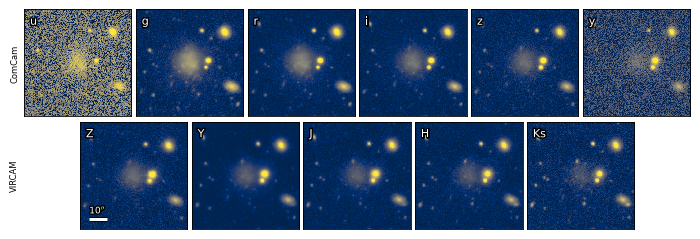

Saved PDF: data/image_products/dp1_ecdfs_11band_cutouts_independent_cividis.pdf
Used independent robust asinh stretch in each band.


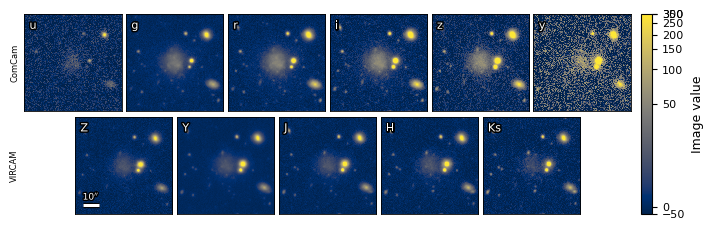

Saved PDF: data/image_products/dp1_ecdfs_11band_cutouts_shared_cividis.pdf
Shared display limits: vmin=-1.7348, vmax=300.499


In [6]:
# ------------------------------------------------------------
# Section 6: create two paper-style figure versions
#   1) independent stretch in each band (better for morphology)
#   2) shared stretch across all bands (better for direct comparison)
# ------------------------------------------------------------

from pathlib import Path


# You can change this quickly if you want to compare styles
CMAP_NAME = "cividis"   # try also: "cividis", "viridis", "gray_r"


def build_panel_norms(use_shared_scale=False):
    """
    Return a dictionary of normalizations for each band.

    If use_shared_scale=False:
        each band gets its own robust asinh stretch.
    If use_shared_scale=True:
        all bands share one common robust asinh stretch.
    """
    if use_shared_scale:
        all_finite = np.concatenate(
            [
                cutout_arrays[band][np.isfinite(cutout_arrays[band])]
                for band in ALL_BANDS
            ]
        )

        shared_norm, shared_vmin, shared_vmax = display_normalization(
            all_finite,
            "shared",
        )

        norms = {
            band: shared_norm
            for band in ALL_BANDS
        }

        scale_info = {
            "mode": "shared",
            "vmin": shared_vmin,
            "vmax": shared_vmax,
        }

    else:
        norms = {}
        per_band_limits = {}

        for band in ALL_BANDS:
            norm, vmin, vmax = display_normalization(
                cutout_arrays[band],
                band,
            )
            norms[band] = norm
            per_band_limits[band] = (vmin, vmax)

        scale_info = {
            "mode": "independent",
            "limits": per_band_limits,
        }

    return norms, scale_info


def plot_cutout_grid(
    use_shared_scale=False,
    cmap_name="cividis",
    show_colorbar=False,
    png_name="cutouts.png",
    pdf_name="cutouts.pdf",
):
    """
    Create one 11-band cutout figure with compact manual layout.
    """
    norms, scale_info = build_panel_norms(
        use_shared_scale=use_shared_scale
    )

    # --------------------------------------------------------
    # Manual geometry
    # This avoids the large empty gap that GridSpec left.
    # --------------------------------------------------------
    fig_w = 7.4
    fig_h = 2.9
    fig = plt.figure(figsize=(fig_w, fig_h))

    label_left = 0.072

    if show_colorbar:
        panel_left = 0.085
        panel_right = 0.905
    else:
        panel_left = 0.085
        panel_right = 0.985

    panel_gap_x = 0.006

    # Width of one top-row panel in figure-normalized units
    panel_w = (
        panel_right
        - panel_left
        - 5 * panel_gap_x
    ) / 6.0

    # Convert to a square panel height in figure-normalized units
    panel_h = panel_w * (fig_w / fig_h)

    # Small vertical gap between rows
    row_gap_y = 0.018

    # Vertical placement
    bottom_y = 0.11
    top_y = bottom_y + panel_h + row_gap_y

    # Bottom row is centred beneath the top row
    bottom_left = panel_left + 0.5 * (panel_w + panel_gap_x)

    axes = {}

    # --------------------------------------------------------
    # Top row: ComCam (6 panels)
    # --------------------------------------------------------
    for i, band in enumerate(COMCAM_BANDS):
        x0 = panel_left + i * (panel_w + panel_gap_x)
        axes[band] = fig.add_axes([x0, top_y, panel_w, panel_h])

    # --------------------------------------------------------
    # Bottom row: VIRCAM (5 panels)
    # --------------------------------------------------------
    for i, band in enumerate(VIRCAM_BANDS):
        x0 = bottom_left + i * (panel_w + panel_gap_x)
        axes[band] = fig.add_axes([x0, bottom_y, panel_w, panel_h])

    # --------------------------------------------------------
    # Draw images
    # --------------------------------------------------------
    mappable = None

    for band in ALL_BANDS:
        ax = axes[band]

        height, width = cutout_arrays[band].shape

        ax.set_facecolor(
            plt.get_cmap(cmap_name)(0.0)
        )

        mappable = ax.imshow(
        cutout_arrays[band],
        origin="lower",
        cmap=cmap_name,
        norm=norms[band],
        interpolation="none",
        )

        ax.set_xlim(-0.5, width - 0.5)
        ax.set_ylim(-0.5, height - 0.5)
        ax.set_aspect("equal", adjustable="box")

        ax.text(
            0.055,
            0.93,
            PANEL_LABELS[band],
            transform=ax.transAxes,
            ha="left",
            va="top",
            color="white",
            fontsize=8,
            path_effects=[
                pe.withStroke(
                    linewidth=2.1,
                    foreground="black",
                )
            ],
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_linewidth(0.6)
            spine.set_color("black")

    # --------------------------------------------------------
    # Row labels
    # --------------------------------------------------------
    fig.text(
        label_left,
        top_y + 0.5 * panel_h,
        "ComCam",
        rotation=90,
        ha="center",
        va="center",
        fontsize=6,
    )

    fig.text(
        label_left,
        bottom_y + 0.5 * panel_h,
        "VIRCAM",
        rotation=90,
        ha="center",
        va="center",
        fontsize=6,
    )

    # --------------------------------------------------------
    # Angular scale bar on first VIRCAM panel
    # --------------------------------------------------------
    scale_axis = axes["Z"]
    bar_length_pix = SCALE_BAR_ARCSEC / PIXEL_SCALE_ARCSEC

    height, width = cutout_arrays["Z"].shape
    bar_x0 = 0.08 * width
    bar_y = 0.09 * height
    bar_x1 = bar_x0 + bar_length_pix

    scale_axis.plot(
        [bar_x0, bar_x1],
        [bar_y, bar_y],
        color="white",
        linewidth=2.2,
        solid_capstyle="butt",
        path_effects=[
            pe.withStroke(
                linewidth=3.8,
                foreground="black",
            )
        ],
    )

    scale_axis.text(
        0.5 * (bar_x0 + bar_x1),
        bar_y + 0.035 * height,
        rf"{SCALE_BAR_ARCSEC:g}$^{{\prime\prime}}$",
        ha="center",
        va="bottom",
        color="white",
        fontsize=6.5,
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground="black",
            )
        ],
    )

    # --------------------------------------------------------
    # Common colorbar only for the shared-scale version
    # --------------------------------------------------------
    if show_colorbar:
        cax = fig.add_axes(
            [
                0.918,
                bottom_y,
                0.016,
                2 * panel_h + row_gap_y,
            ]
        )
        cbar = fig.colorbar(mappable, cax=cax)
        cbar.set_label(
            "Image value",
            fontsize=9,
        )
        cbar.ax.tick_params(labelsize=8)

    # --------------------------------------------------------
    # Save and show
    # --------------------------------------------------------
    png_path = OUTDIR / png_name
    pdf_path = OUTDIR / pdf_name

    fig.savefig(
        pdf_path,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.025,
    )

    plt.show()

    print("Saved PDF:", pdf_path)

    if use_shared_scale:
        print(
            f"Shared display limits: "
            f"vmin={scale_info['vmin']:.6g}, "
            f"vmax={scale_info['vmax']:.6g}"
        )
    else:
        print("Used independent robust asinh stretch in each band.")


# ------------------------------------------------------------
# Make both versions so you can compare them
# ------------------------------------------------------------

# 1) Better for morphology / appearance in each band
plot_cutout_grid(
    use_shared_scale=False,
    cmap_name=CMAP_NAME,
    show_colorbar=False,
    pdf_name="dp1_ecdfs_11band_cutouts_independent_cividis.pdf",
)

# 2) Better for direct band-to-band display comparison
plot_cutout_grid(
    use_shared_scale=True,
    cmap_name=CMAP_NAME,
    show_colorbar=True,
    pdf_name="dp1_ecdfs_11band_cutouts_shared_cividis.pdf",
)

